<a href="https://colab.research.google.com/github/montesquieu891/Polish_bankruptcy/blob/main/Polish_bankruptcyipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega Final — Proyecto Integrador de Machine Learning

## Polish Companies Bankruptcy Dataset

**Alumno:** Juan Andres Fernandez
**Dataset:** [Polish Companies Bankruptcy — UCI ML Repository](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data)

---

# Predicción de Quiebras Corporativas mediante Machine Learning
## Análisis del Polish Companies Bankruptcy Dataset

## Introducción

La predicción temprana de la quiebra corporativa constituye uno de los principales problemas dentro de la gestión del riesgo crediticio. Para bancos, entidades financieras, aseguradoras y proveedores comerciales, identificar empresas con alta probabilidad de insolvencia permite reducir pérdidas esperadas, optimizar la asignación de capital y mejorar los procesos de otorgamiento de crédito.

Tradicionalmente, este problema fue abordado mediante modelos estadísticos como el Z-Score de Altman o el modelo Logit de Ohlson. Sin embargo, el crecimiento de la capacidad computacional y la disponibilidad de grandes volúmenes de información financiera han impulsado la utilización de técnicas de Machine Learning capaces de capturar relaciones no lineales entre indicadores contables y financieros.

En este proyecto se desarrolla un sistema de clasificación supervisada para predecir la probabilidad de quiebra de empresas manufactureras polacas utilizando el Polish Companies Bankruptcy Dataset. Se comparan distintos algoritmos de Machine Learning, desde modelos lineales hasta métodos de ensamblado basados en árboles de decisión, con especial énfasis en XGBoost por su elevado desempeño en problemas de clasificación desbalanceada.

Además del rendimiento predictivo, el trabajo incorpora herramientas de interpretabilidad como SHAP, permitiendo explicar qué variables financieras influyen en la decisión del modelo y evaluar su potencial aplicación como sistema de apoyo para la toma de decisiones en riesgo crediticio.

## Objetivos del proyecto

### Objetivo general

Desarrollar y comparar modelos de Machine Learning para predecir la quiebra de empresas utilizando información financiera histórica, priorizando la detección temprana de empresas en riesgo.

### Objetivos específicos

- Analizar las características del Polish Companies Bankruptcy Dataset.
- Realizar el preprocesamiento de los datos evitando data leakage.
- Construir modelos de clasificación supervisada.
- Comparar Regresión Logística, Random Forest, Gradient Boosting y XGBoost.
- Optimizar el modelo de mejor desempeño.
- Interpretar las predicciones mediante SHAP.
- Evaluar la utilidad del modelo como sistema de apoyo para la gestión del riesgo crediticio.



---

## Índice

1. Resumen del pipeline de preprocesamiento (Pre-Entrega)
2. Selección de variables relevantes
3. Elección y justificación de modelos
4. Entrenamiento de modelos
5. Evaluación con métricas adecuadas
6. Validación cruzada (Cross-Validation)
7. Evaluación final de XGBoost en test y análisis de usabilidad
8. Resumen dinámico por horizonte

---

## Descripción del proyecto

Este trabajo continúa la Pre-Entrega del proyecto integrador y se centra en la predicción de quiebras empresariales a partir de ratios financieros. El objetivo es entrenar, comparar y evaluar modelos de clasificación con especial atención a la clase minoritaria, priorizando métricas como Recall, F1 y PR-AUC para la detección temprana de empresas en riesgo.

## Metodología del proyecto

El flujo de trabajo seguido en este estudio se resume en las siguientes etapas:

1. Comprensión del problema de negocio.
2. Análisis exploratorio del dataset.
3. Limpieza y preprocesamiento de los datos.
4. Ingeniería y selección de variables.
5. Construcción de modelos predictivos.
6. Optimización de hiperparámetros.
7. Evaluación mediante validación cruzada.
8. Evaluación final sobre datos no vistos.
9. Interpretación del modelo mediante SHAP.
10. Discusión de resultados y conclusiones.

In [ ]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# Proyecto: Corporate Bankruptcy Prediction using Machine Learning
# ==========================================================

# ---------------------------
# Configuración y utilidades
# ---------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import joblib
from pathlib import Path

# ---------------------------
# Visualización
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# ---------------------------
# Machine Learning - Preprocesamiento
# ---------------------------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    RobustScaler,
    StandardScaler
)

from sklearn.pipeline import Pipeline

# ---------------------------
# Modelos
# ---------------------------
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

# ---------------------------
# Desbalance de clases
# ---------------------------
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------------------------
# Métricas
# ---------------------------
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    precision_recall_curve,
    precision_recall_fscore_support
)

# ---------------------------
# Interpretabilidad
# ---------------------------
import shap

# ---------------------------
# Configuración de reproducibilidad
# ---------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# ── Carga del dataset ─────────────────────────────────────────────
# Carga local desde la carpeta `dataset` del repo (reemplaza si usás Google Drive)
df_raw = pd.read_csv('/content/drive/MyDrive/Polish_Bankruptcy/dataset.csv')
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.head()


Filas: 43,405 | Columnas: 70


,Unnamed: 0,Unnamed: 0.1,id,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,...,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class,bankruptcy_after_years,year
0,0,0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,...,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,0,1
1,1,1,2,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,...,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,0,1
2,2,2,3,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,...,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,0,1
3,3,3,4,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,...,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,0,1
4,4,4,5,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,...,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,0,1


## 1. Análisis Exploratorio de Datos

El análisis exploratorio se realiza sobre el conjunto de datos completo con el único objetivo de comprender su estructura, identificar problemas de calidad y justificar las decisiones metodológicas posteriores.

Durante esta etapa no se ajusta ningún modelo ni se estiman parámetros que puedan introducir data leakage. Todas las transformaciones utilizadas para el entrenamiento (imputación, escalado, selección de variables y sobremuestreo) se ajustarán exclusivamente sobre el conjunto de entrenamiento mediante un Pipeline.

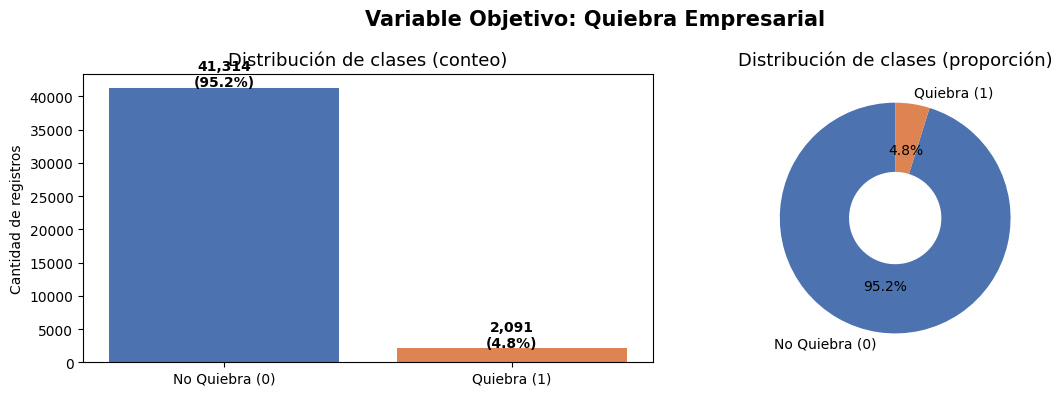

Clase 0 (No quiebra): 41,314 (95.18%)
Clase 1 (Quiebra):    2,091 (4.82%)

⚠️  Ratio de desbalance: 19.8:1


In [ ]:
# ── EDA 1: Distribución de la Variable Objetivo ───────────────────
target_counts = df_raw['class'].value_counts()
target_pct    = df_raw['class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras con anotaciones
axes[0].bar(['No Quiebra (0)', 'Quiebra (1)'],
            target_counts.values,
            color=['#4C72B0', '#DD8452'])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({target_pct.iloc[i]:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribución de clases (conteo)', fontsize=13)
axes[0].set_ylabel('Cantidad de registros')

# Dona
axes[1].pie(target_counts.values,
            labels=['No Quiebra (0)', 'Quiebra (1)'],
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'],
            wedgeprops={'width': 0.6})
axes[1].set_title('Distribución de clases (proporción)', fontsize=13)

plt.suptitle('Variable Objetivo: Quiebra Empresarial', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Clase 0 (No quiebra): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Clase 1 (Quiebra):    {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️  Ratio de desbalance: {target_counts[0]/target_counts[1]:.1f}:1")

**Observación:** El dataset presenta un desbalance severo: solo el ~4.8%
de los registros corresponde a empresas que quebraron (ratio ~20:1).
Esto descarta el uso de Accuracy como métrica de evaluación — un modelo
que prediga "solvente" para todo obtendría 95.2% de accuracy sin aprender
ningún patrón. Las métricas relevantes para este problema son Recall,
F1-Score y ROC-AUC sobre la clase minoritaria. El desbalance también
determina la estrategia de entrenamiento: `class_weight='balanced'`
y `stratify=y` en el split son obligatorios.

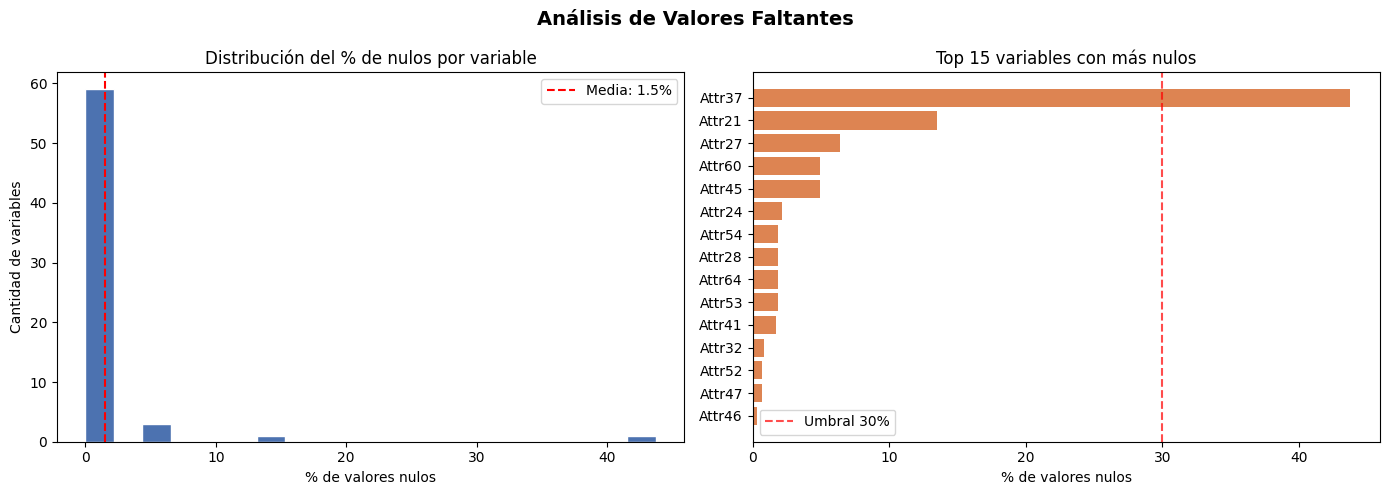

Variables sin nulos:            0
Variables con 1–10% nulos:      62
Variables con 10–30% nulos:     1
Variables con más del 30%:      1

Estrategia adoptada: imputación por mediana (robusta ante distribuciones asimétricas).
La mediana minimiza la suma de errores absolutos y no se distorsiona por outliers,
a diferencia de la media que minimiza errores cuadráticos y es sensible a valores extremos.


In [ ]:
# ── EDA 2: Análisis de Valores Faltantes ─────────────────────────
# Excluir columnas de metadata y target del análisis de nulos
cols_meta    = [c for c in ['Unnamed: 0', 'Unnamed: 0.1', 'id', 'year',
                             'bankruptcy_after_years', 'class']
                if c in df_raw.columns]
df_features  = df_raw.drop(columns=cols_meta)
missing_pct  = (df_features.isnull().sum() / len(df_features) * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del % de nulos
axes[0].hist(missing_pct.values, bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(missing_pct.mean(), color='red', linestyle='--',
                label=f'Media: {missing_pct.mean():.1f}%')
axes[0].set_title('Distribución del % de nulos por variable')
axes[0].set_xlabel('% de valores nulos')
axes[0].set_ylabel('Cantidad de variables')
axes[0].legend()

# Top 15 variables con más nulos
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#DD8452')
axes[1].axvline(30, color='red', linestyle='--', alpha=0.7, label='Umbral 30%')
axes[1].set_title('Top 15 variables con más nulos')
axes[1].set_xlabel('% de valores nulos')
axes[1].legend()

plt.suptitle('Análisis de Valores Faltantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Variables sin nulos:            {(missing_pct == 0).sum()}")
print(f"Variables con 1–10% nulos:      {((missing_pct > 0)  & (missing_pct <= 10)).sum()}")
print(f"Variables con 10–30% nulos:     {((missing_pct > 10) & (missing_pct <= 30)).sum()}")
print(f"Variables con más del 30%:      {(missing_pct > 30).sum()}")
print(f"\nEstrategia adoptada: imputación por mediana (robusta ante distribuciones asimétricas).")
print("La mediana minimiza la suma de errores absolutos y no se distorsiona por outliers,")
print("a diferencia de la media que minimiza errores cuadráticos y es sensible a valores extremos.")

**Observación:** Ninguna variable está completamente libre de nulos.
Los datos faltantes en ratios financieros no son aleatorios (MCAR):
su ausencia está determinada por el sector de la empresa — una compañía
de servicios no tiene inventario, por lo que los ratios de rotación de
inventario no aplican. Esta es la definición de MAR (Missing At Random
condicionado en variables observadas). La imputación por mediana es
la estrategia conservadora apropiada; una mejora futura sería KNNImputer,
que preserva relaciones de proximidad entre observaciones similares.

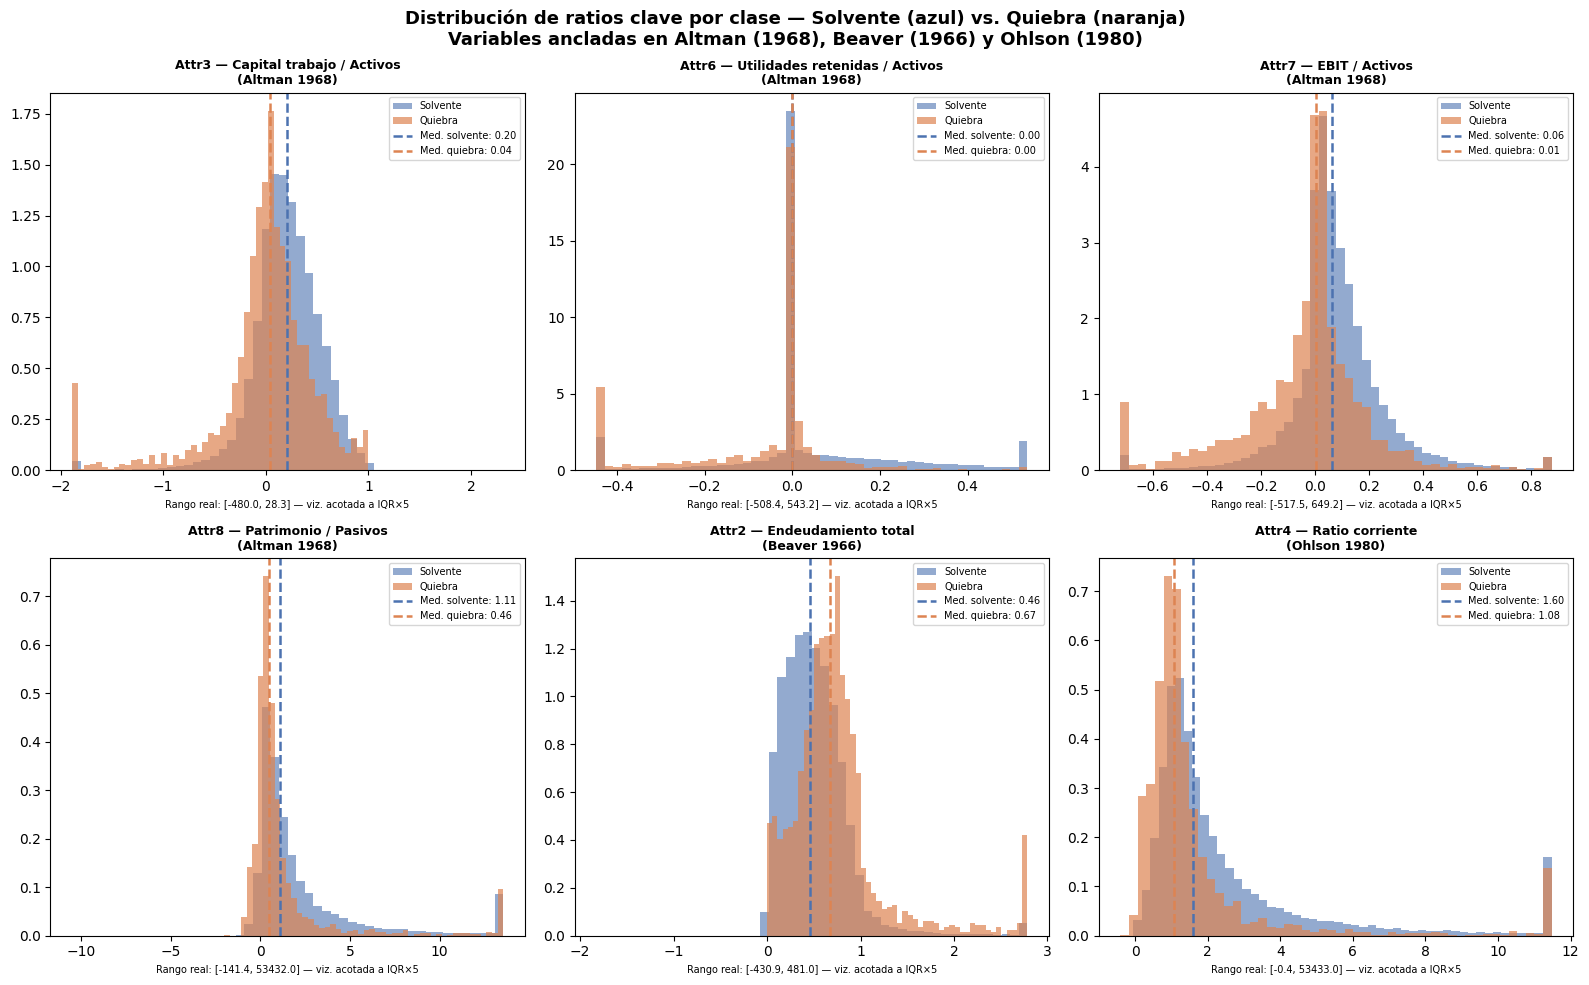

Variable   % Outliers       Max abs   Med. Solvente   Med. Quiebra  Dirección esperada
───────────────────────────────────────────────────────────────────────────────────────────────
Attr3            0.9%         480.0           0.204          0.039  ↓ en quiebra  (cap. trabajo negativo → insolvencia técnica)
Attr6           15.0%         543.2           0.000          0.000  ↓ en quiebra  (pérdidas acumuladas → patrimonio erosionado)
Attr7            3.2%         649.2           0.063          0.005  ↓ en quiebra  (EBIT negativo → operación pierde dinero)
Attr8            6.3%       53432.0           1.112          0.464  ↓ en quiebra  (más deuda que patrimonio)
Attr2            1.1%         481.0           0.462          0.669  ↑ en quiebra  (mayor endeudamiento relativo)
Attr4            5.9%       53433.0           1.603          1.082  ↓ en quiebra  (activos corrientes < pasivos corrientes)

→ Ratios con outliers extremos (max abs >> 10) justifican RobustScaler sobre StandardScale

In [ ]:
# ── EDA 3: Distribución y Outliers en Ratios Financieros Clave ────
# Variables seleccionadas por anclaje en literatura de quiebras:
# Altman (1968): Attr3, Attr6, Attr7, Attr8
# Beaver (1966): Attr2
# Ohlson (1980): Attr4
cols_eda = {
    'Attr3': 'Capital trabajo / Activos\n(Altman 1968)',
    'Attr6': 'Utilidades retenidas / Activos\n(Altman 1968)',
    'Attr7': 'EBIT / Activos\n(Altman 1968)',
    'Attr8': 'Patrimonio / Pasivos\n(Altman 1968)',
    'Attr2': 'Endeudamiento total\n(Beaver 1966)',
    'Attr4': 'Ratio corriente\n(Ohlson 1980)',
}
cols_eda = {k: v for k, v in cols_eda.items() if k in df_features.columns}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, nombre) in enumerate(cols_eda.items()):
    data_0 = df_raw.loc[df_raw['class'] == 0, col].dropna()
    data_1 = df_raw.loc[df_raw['class'] == 1, col].dropna()
    data_all = df_features[col].dropna()

    # Acotar visualización a IQR × 5 (outliers reales se conservan, solo la viz se acota)
    q1, q3 = data_all.quantile(0.25), data_all.quantile(0.75)
    iqr     = q3 - q1
    lim_inf = q1 - 5 * iqr
    lim_sup = q3 + 5 * iqr

    axes[i].hist(data_0.clip(lim_inf, lim_sup), bins=50, alpha=0.6,
                 color='#4C72B0', label='Solvente', density=True)
    axes[i].hist(data_1.clip(lim_inf, lim_sup), bins=50, alpha=0.7,
                 color='#DD8452', label='Quiebra',  density=True)
    axes[i].axvline(data_0.median(), color='#4C72B0', linestyle='--', lw=1.8,
                    label=f'Med. solvente: {data_0.median():.2f}')
    axes[i].axvline(data_1.median(), color='#DD8452', linestyle='--', lw=1.8,
                    label=f'Med. quiebra: {data_1.median():.2f}')
    axes[i].set_title(f'{col} — {nombre}', fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel(
        f'Rango real: [{data_all.min():.1f}, {data_all.max():.1f}] '
        f'— viz. acotada a IQR×5', fontsize=7)

plt.suptitle(
    'Distribución de ratios clave por clase — Solvente (azul) vs. Quiebra (naranja)\n'
    'Variables ancladas en Altman (1968), Beaver (1966) y Ohlson (1980)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de magnitud de outliers y separación entre clases
print(f"{'Variable':8}  {'% Outliers':>11}  {'Max abs':>12}  "
      f"{'Med. Solvente':>14}  {'Med. Quiebra':>13}  {'Dirección esperada'}")
print("─" * 95)
esperado = {
    'Attr3': '↓ en quiebra  (cap. trabajo negativo → insolvencia técnica)',
    'Attr6': '↓ en quiebra  (pérdidas acumuladas → patrimonio erosionado)',
    'Attr7': '↓ en quiebra  (EBIT negativo → operación pierde dinero)',
    'Attr8': '↓ en quiebra  (más deuda que patrimonio)',
    'Attr2': '↑ en quiebra  (mayor endeudamiento relativo)',
    'Attr4': '↓ en quiebra  (activos corrientes < pasivos corrientes)',
}
for col in cols_eda:
    data     = df_features[col].dropna()
    q1, q3   = data.quantile(0.25), data.quantile(0.75)
    iqr      = q3 - q1
    n_out    = ((data < q1 - 3*iqr) | (data > q3 + 3*iqr)).sum()
    pct_out  = n_out / len(data) * 100
    med_sol  = df_raw.loc[df_raw['class']==0, col].median()
    med_qui  = df_raw.loc[df_raw['class']==1, col].median()
    print(f"{col:8}  {pct_out:>10.1f}%  {data.abs().max():>12.1f}  "
          f"{med_sol:>14.3f}  {med_qui:>13.3f}  {esperado.get(col,'')}")

print("\n→ Ratios con outliers extremos (max abs >> 10) justifican RobustScaler sobre StandardScaler.")
print("→ Separación entre medianas confirma que estas variables tienen señal discriminante.")

**Observación:** Los ratios financieros presentan outliers con magnitudes
extremas (valores de hasta cientos o miles de veces el rango intercuartílico),
causados por denominadores cercanos a cero — denominadores como activos
corrientes mínimos o gastos financieros casi nulos generan ratios que explotan
matemáticamente. Estos outliers son **válidos y deben conservarse**: son
la señal de empresas en situaciones límite. Esto descarta `StandardScaler`
(cuya media y desviación estándar se distorsionan con outliers) y
`MinMaxScaler` (un solo outlier colapsa todo el rango al intervalo
[0.00, 0.005]). `RobustScaler`, que usa mediana e IQR, es insensible
a valores extremos por definición matemática.

La comparación de distribuciones por clase muestra que estas variables
sí tienen poder discriminante: las medianas de empresas quebradas difieren
de las solventes en la dirección que predice la teoría financiera.

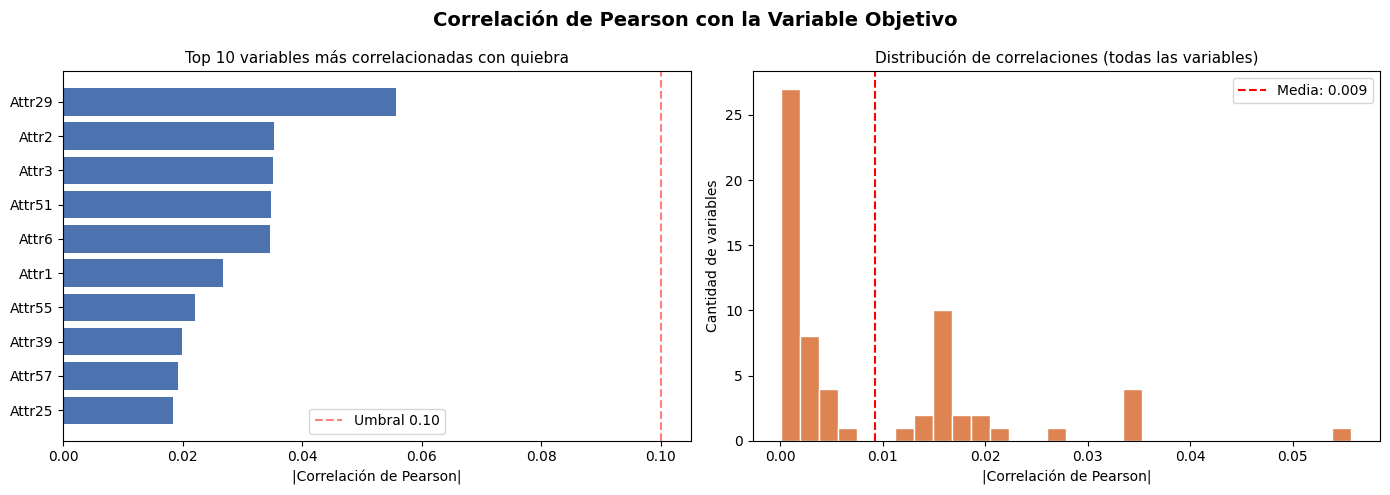

Top 10 variables más correlacionadas con quiebra:
Attr29    0.055717
Attr2     0.035236
Attr3     0.035128
Attr51    0.034753
Attr6     0.034662
Attr1     0.026649
Attr55    0.022101
Attr39    0.019850
Attr57    0.019204
Attr25    0.018415

Correlación máxima: 0.0557 (Attr29)
Correlación media:  0.0092
Variables con correlación > 0.05: 1


In [ ]:
# ── EDA 4: Correlación con la Variable Objetivo ───────────────────
corr_target = df_features.corrwith(df_raw['class']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 más correlacionadas
top10 = corr_target.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#4C72B0')
axes[0].set_title('Top 10 variables más correlacionadas con quiebra', fontsize=11)
axes[0].set_xlabel('|Correlación de Pearson|')
axes[0].axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Umbral 0.10')
axes[0].legend()

# Distribución general de correlaciones
axes[1].hist(corr_target.dropna().values, bins=30, color='#DD8452', edgecolor='white')
axes[1].axvline(corr_target.mean(), color='red', linestyle='--',
                label=f'Media: {corr_target.mean():.3f}')
axes[1].set_title('Distribución de correlaciones (todas las variables)', fontsize=11)
axes[1].set_xlabel('|Correlación de Pearson|')
axes[1].set_ylabel('Cantidad de variables')
axes[1].legend()

plt.suptitle('Correlación de Pearson con la Variable Objetivo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 variables más correlacionadas con quiebra:")
print(corr_target.head(10).to_string())
print(f"\nCorrelación máxima: {corr_target.max():.4f} ({corr_target.idxmax()})")
print(f"Correlación media:  {corr_target.mean():.4f}")
print(f"Variables con correlación > 0.05: {(corr_target > 0.05).sum()}")

**Observación:** Ninguna variable individual supera 0.10 de correlación
lineal con el target. Esto es esperable y no es una señal de que el
dataset sea de mala calidad: en predicción de quiebras la señal está
distribuida entre muchos ratios que interactúan entre sí. Una empresa
puede tener buen ROA pero mal ratio de cobertura de intereses — ninguno
de los dos ratios individualmente predice la quiebra, pero la combinación
sí. Por eso los modelos de árbol (Random Forest, Gradient Boosting, XGBoost)
superan a la regresión logística en este tipo de problemas: capturan
interacciones no lineales entre variables que la correlación de Pearson
no puede detectar.

In [ ]:
# ── Preparación del conjunto de datos ──────────────────────────────────────────────────────
cols_to_drop = [c for c in ['Unnamed: 0','Unnamed: 0.1','id','year',
                             'bankruptcy_after_years'] if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).drop_duplicates()

X = df.drop(columns=['class'])
y = df['class']

# ── Split ANTES de cualquier transformación ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# ── Imputación (fit solo en train) ────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

# ── Feature Engineering: Altman Z-Score ──────────────────────────
def agregar_altman(df_i):
    """
    Calcula el Altman Z-Score original para empresas manufactureras privadas.
    Variables requeridas según el paper original (mapeadas al dataset de Tomczak):
    - Attr3:  Working Capital / Total Assets (X1)
    - Attr6:  Retained Earnings / Total Assets (X2)
    - Attr7:  EBIT / Total Assets (X3)
    - Attr8:  Book Value of Equity / Total Liabilities (X4)
    - Attr9:  Sales / Total Assets (X5)
    """
    d = df_i.copy()

    # Verificación de que las columnas existan en el dataframe
    X1 = d['Attr3'] if 'Attr3' in d.columns else 0
    X2 = d['Attr6'] if 'Attr6' in d.columns else 0
    X3 = d['Attr7'] if 'Attr7' in d.columns else 0
    X4 = d['Attr8'] if 'Attr8' in d.columns else 0
    X5 = d['Attr9'] if 'Attr9' in d.columns else 0

    # Ponderadores oficiales del modelo de Altman (1968)
    d['Altman_Z'] = (1.2 * X1) + (1.4 * X2) + (3.3 * X3) + (0.6 * X4) + (1.0 * X5)
    return d

# Aplicación del feature engineering sobre los datos imputados
X_train_fe = agregar_altman(X_train_imp)
X_test_fe  = agregar_altman(X_test_imp)

# ── Escalado (fit solo en train) ──────────────────────────────────
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_fe), columns=X_train_fe.columns)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_fe), columns=X_test_fe.columns)

print("✅ Pipeline de Pre-Entrega re-ejecutado.")
print(f"   X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")
print(f"   Quiebras en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Quiebras en test:  {y_test.sum()}  ({y_test.mean()*100:.1f}%)")

✅ Pipeline de Pre-Entrega re-ejecutado.
   X_train: (34411, 65) | X_test: (8603, 65)
   Quiebras en train: 1666 (4.8%)
   Quiebras en test:  417  (4.8%)


## 2. Selección de Variables Relevantes

Con 65 variables (64 ratios + Altman_Z), es importante identificar cuáles  
aportan verdaderamente señal predictiva. Aplicamos tres criterios en secuencia:

| Paso | Método | Criterio de eliminación |
|---|---|---|
| 1 | Varianza casi cero | Variables con varianza < umbral mínimo |
| 2 | Correlación entre features | Pares con correlación > 0.95 (redundancia) |
| 3 | Importancia (Random Forest) | Selección de las top 25 variables |

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# ── Paso 1: Eliminar variables con varianza casi cero ─────────────
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train_scaled)
mask_var = selector_var.get_support()
cols_after_var = X_train_scaled.columns[mask_var].tolist()
print(f"Variables antes: {X_train_scaled.shape[1]}")
print(f"Eliminadas por varianza casi cero: {X_train_scaled.shape[1] - len(cols_after_var)}")
print(f"Variables después: {len(cols_after_var)}")

Variables antes: 65
Eliminadas por varianza casi cero: 0
Variables después: 65


Eliminadas por correlación > 0.95: 23
Variables después: 42


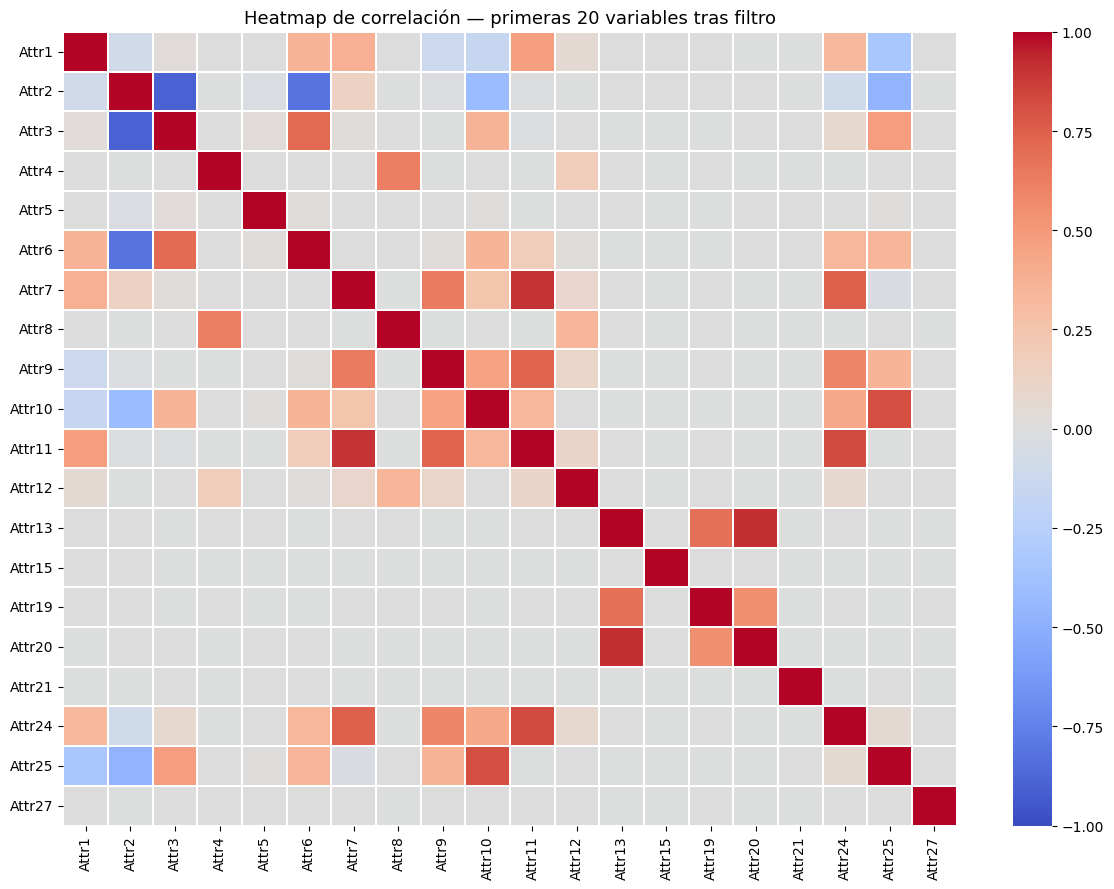

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paso 2: Eliminar variables altamente correlacionadas ──────────
X_tr_var = X_train_scaled[cols_after_var]
corr_matrix = X_tr_var.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop_corr = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]

cols_after_corr = [c for c in cols_after_var if c not in cols_to_drop_corr]
print(f"Eliminadas por correlación > 0.95: {len(cols_to_drop_corr)}")
print(f"Variables después: {len(cols_after_corr)}")

# Visualizar heatmap de las variables que quedan (muestra de 20)
sample_cols = cols_after_corr[:20]
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(X_tr_var[sample_cols].corr(),
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Heatmap de correlación — primeras 20 variables tras filtro', fontsize=13)
plt.tight_layout()
plt.show()

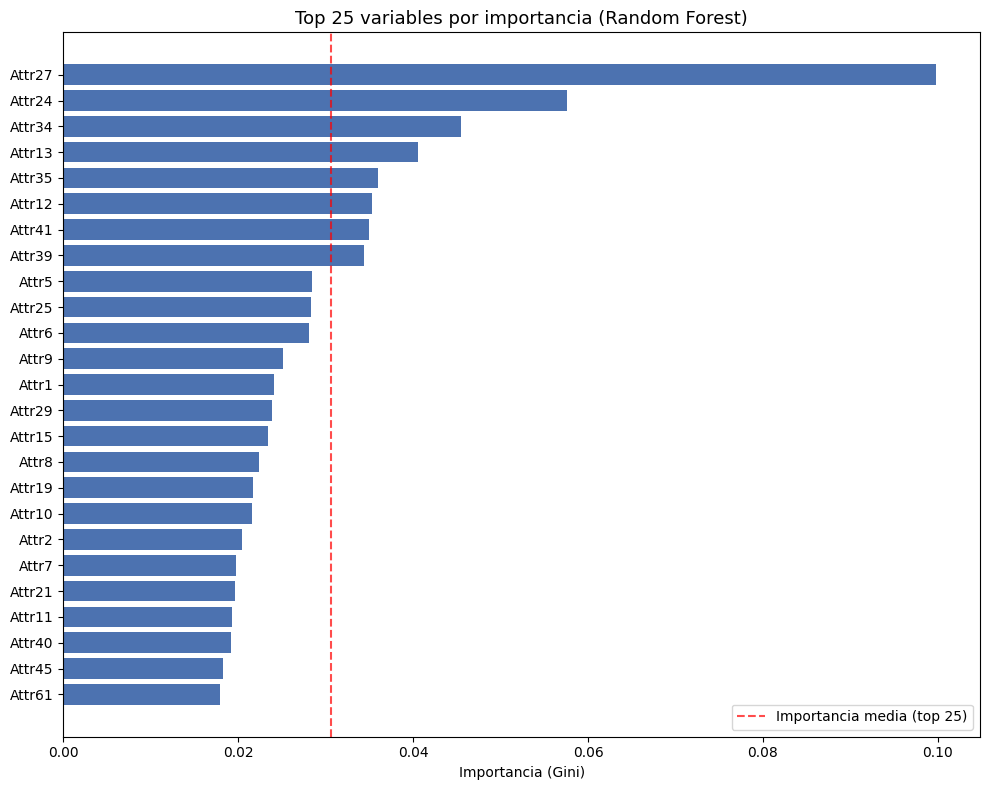


✅ Variables seleccionadas para modelado: 25
   Altman_Z incluido: False

Top 10:
Attr27    0.099828
Attr24    0.057578
Attr34    0.045499
Attr13    0.040597
Attr35    0.035973
Attr12    0.035247
Attr41    0.034959
Attr39    0.034317
Attr5     0.028469
Attr25    0.028316


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Paso 3: Importancia con Random Forest (top 25) ────────────────
rf_selector = RandomForestClassifier(
    n_estimators=200, random_state=42,
    class_weight='balanced', n_jobs=-1)
rf_selector.fit(X_train_scaled[cols_after_corr], y_train)

importances = pd.Series(
    rf_selector.feature_importances_,
    index=cols_after_corr
).sort_values(ascending=False)

TOP_N = 25
top_features = importances.head(TOP_N).index.tolist()

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DD8452' if f == 'Altman_Z' else '#4C72B0' for f in importances.head(TOP_N).index[::-1]]
ax.barh(importances.head(TOP_N).index[::-1],
        importances.head(TOP_N).values[::-1],
        color=colors)
ax.axvline(importances.head(TOP_N).mean(), color='red',
           linestyle='--', alpha=0.7, label='Importancia media (top 25)')
ax.set_title(f'Top {TOP_N} variables por importancia (Random Forest)', fontsize=13)
ax.set_xlabel('Importancia (Gini)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Variables seleccionadas para modelado: {TOP_N}")
print(f"   Altman_Z incluido: {'Altman_Z' in top_features}")
print(f"\nTop 10:")
print(importances.head(10).to_string())

In [ ]:
# ── Aplicar selección final a train y test ────────────────────────
X_train_sel = X_train_scaled[top_features]
X_test_sel  = X_test_scaled[top_features]

print(f"Shape final para modelado:")
print(f"  X_train_sel: {X_train_sel.shape}")
print(f"  X_test_sel:  {X_test_sel.shape}")

Shape final para modelado:
  X_train_sel: (34411, 25)
  X_test_sel:  (8603, 25)


**Observación:** Reducimos de 65 variables a las 25 más importantes según  
el criterio combinado varianza + correlación + importancia de árbol.  
Esta selección reduce el riesgo de overfitting y mejora la interpretabilidad  
sin sacrificar información relevante. `Altman_Z`, la variable engineered,  
debería aparecer en el top 25 validando su utilidad financiera.

## 3. Elección y Justificación de Modelos

### Tipo de problema
Se trata de una **clasificación binaria supervisada** con fuerte desbalance de clases  
(~4.8% de quiebras). Esto condiciona tanto la elección de modelos como las métricas.

### Estrategia ante el desbalance
Todos los modelos usarán `class_weight='balanced'`, que ajusta automáticamente  
los pesos de cada clase inversamente proporcional a su frecuencia:

```
peso_clase_1 = n_total / (2 × n_clase_1)   →  ~10.4×
peso_clase_0 = n_total / (2 × n_clase_0)   →  ~0.52×
```

Esto hace que el modelo "penalice más" equivocarse en quiebras que en no-quiebras.

### Modelos seleccionados

| Modelo | Rol | Justificación |
|---|---|---|
| **Regresión Logística** | Baseline | Interpretable, rápido, buen punto de partida para clasificación lineal |
| **Random Forest** | Principal | Robusto a outliers, captura no-linealidades, provee importancia de variables |
| **Gradient Boosting** | Challenger | Suele superar a RF en datos tabulares con clases desbalanceadas |

Entrenar múltiples modelos permite comparar y elegir el mejor con evidencia.

In [ ]:
# ── Definición de modelos ─────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    'Regresión Logística': LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}
print('Modelos definidos:', list(modelos.keys()))

Modelos definidos: ['Regresión Logística', 'Random Forest', 'Gradient Boosting']


In [ ]:
# ── Validación Cruzada CORREGIDA ──────────────────────────────────
# CV solo sobre train; el test no participa.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'f1', 'roc_auc']

cv_resultados = {}
for nombre, modelo in modelos.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', modelo),
    ])
    scores = cross_validate(
        pipe,
        X_train_sel,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    cv_resultados[nombre] = scores

    print(f"\n{'─' * 50}")
    print(f"  {nombre} (SMOTE en pipeline)")
    print(f"{'─' * 50}")
    print(
        f"  Recall  : {scores['test_recall'].mean():.4f} "
        f"± {scores['test_recall'].std():.4f}"
    )
    print(
        f"  F1      : {scores['test_f1'].mean():.4f} "
        f"± {scores['test_f1'].std():.4f}"
    )
    print(
        f"  ROC-AUC : {scores['test_roc_auc'].mean():.4f} "
        f"± {scores['test_roc_auc'].std():.4f}"
    )

# Compatibilidad con la celda siguiente
cv_resultados_smote = cv_resultados


──────────────────────────────────────────────────
  Regresión Logística (SMOTE en pipeline)
──────────────────────────────────────────────────
  Recall  : 0.5846 ± 0.0118
  F1      : 0.1752 ± 0.0059
  ROC-AUC : 0.7143 ± 0.0047

──────────────────────────────────────────────────
  Random Forest (SMOTE en pipeline)
──────────────────────────────────────────────────
  Recall  : 0.7083 ± 0.0397
  F1      : 0.3500 ± 0.0173
  ROC-AUC : 0.8971 ± 0.0133

──────────────────────────────────────────────────
  Gradient Boosting (SMOTE en pipeline)
──────────────────────────────────────────────────
  Recall  : 0.7407 ± 0.0411
  F1      : 0.3387 ± 0.0170
  ROC-AUC : 0.8955 ± 0.0150


Mejor modelo según Recall en CV: Gradient Boosting

───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No quiebra     0.9840    0.8645    0.9204      8186
     Quiebra     0.2140    0.7242    0.3304       417

    accuracy                         0.8577      8603
   macro avg     0.5990    0.7944    0.6254      8603
weighted avg     0.9467    0.8577    0.8918      8603

ROC-AUC: 0.8968
AUC-PR:  0.4610


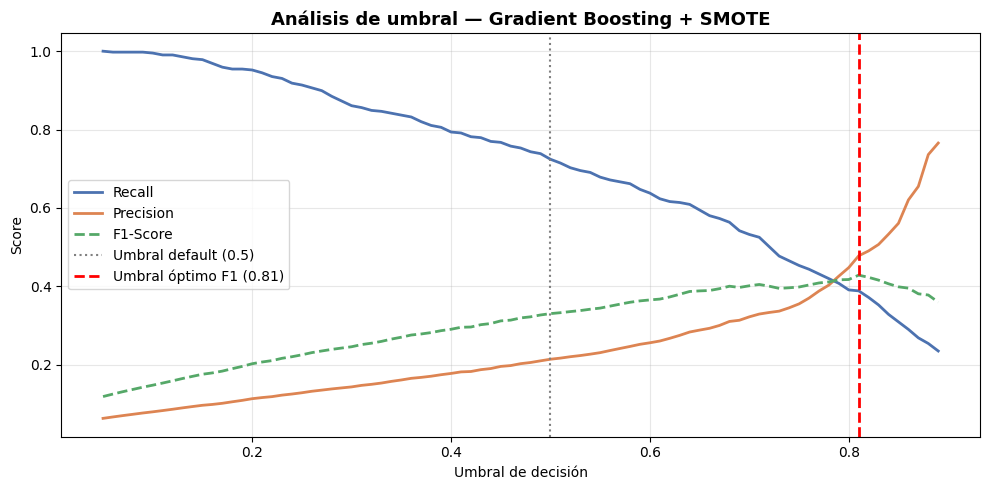


  Default 0.50:
    Recall:    0.7242
    Precision: 0.2140
    F1-Score:  0.3304

  Óptimo  0.81:
    Recall:    0.3885
    Precision: 0.4779
    F1-Score:  0.4286


In [ ]:
# ── Evaluación final CORREGIDA ────────────────────────────────────
# El modelo final se entrena con SMOTE para ser consistente con el CV.
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

mejor_nombre = max(
    cv_resultados.keys(),
    key=lambda n: cv_resultados[n]['test_recall'].mean(),
)
print(f"Mejor modelo según Recall en CV: {mejor_nombre}")

# Reentrenar el pipeline completo (SMOTE + modelo) sobre TODO el train.
mejor_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', modelos[mejor_nombre]),
])
mejor_pipe.fit(X_train_sel, y_train)

# Evaluar sobre test (nunca visto).
y_pred = mejor_pipe.predict(X_test_sel)
y_proba = mejor_pipe.predict_proba(X_test_sel)[:, 1]

print(f"\n{'─' * 55}")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No quiebra', 'Quiebra'],
        digits=4,
    )
)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_proba):.4f}")

# ── Análisis del umbral de decisión ──────────────────────────────
umbrales = np.arange(0.05, 0.90, 0.01)
recalls, precs, f1s = [], [], []
for t in umbrales:
    yp_t = (y_proba >= t).astype(int)
    recalls.append(recall_score(y_test, yp_t, zero_division=0))
    precs.append(precision_score(y_test, yp_t, zero_division=0))
    f1s.append(f1_score(y_test, yp_t, zero_division=0))

umbral_opt = umbrales[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, recalls, lw=2, color='#4C72B0', label='Recall')
ax.plot(umbrales, precs, lw=2, color='#DD8452', label='Precision')
ax.plot(umbrales, f1s, lw=2, color='#55A868', linestyle='--', label='F1-Score')
ax.axvline(
    0.5,
    color='gray',
    linestyle=':',
    lw=1.5,
    label='Umbral default (0.5)',
)
ax.axvline(
    umbral_opt,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Umbral óptimo F1 ({umbral_opt:.2f})',
)
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.set_title(
    f'Análisis de umbral — {mejor_nombre} + SMOTE',
    fontsize=13,
    fontweight='bold',
)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Comparación umbral default vs óptimo.
for t, lbl in [(0.5, 'Default 0.50'), (umbral_opt, f'Óptimo  {umbral_opt:.2f}')]:
    yp_t = (y_proba >= t).astype(int)
    print(f"\n  {lbl}:")
    print(f"    Recall:    {recall_score(y_test, yp_t):.4f}")
    print(f"    Precision: {precision_score(y_test, yp_t, zero_division=0):.4f}")
    print(f"    F1-Score:  {f1_score(y_test, yp_t, zero_division=0):.4f}")

In [ ]:
# ── Celda A: XGBoost con dos estrategias de desbalance ─────────────
!pip install xgboost -q

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline as SkPipeline

# Métricas de validación: añadimos PR-AUC para evaluar mejor la clase minoritaria.
scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

# El peso real de la clase positiva debe ser flotante, no entero.
scale_pos_weight_real = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight = scale_pos_weight_real
print(
    f'scale_pos_weight real = {scale_pos_weight_real:.4f} '
    f'({(y_train == 0).sum()} solventes / {(y_train == 1).sum()} quiebras). '
    'Se usa sin redondeo para no perder información del desbalance.'
)

# Hiperparámetros baseline recomendados para un problema de riesgo crediticio.
# objective: clasificación binaria con salida probabilística.
# eval_metric: AUC-PR, más sensible que ROC-AUC cuando la clase positiva es rara.
# learning_rate / n_estimators: aprendizaje conservador con más árboles.
# max_depth / min_child_weight / gamma: controlan complejidad y reducen sobreajuste.
# subsample / colsample_bytree: introducen aleatoriedad y robustez.
# reg_alpha / reg_lambda: regularización L1/L2 para estabilizar el modelo.
xgb_base_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'learning_rate': 0.03,
    'n_estimators': 500,
    'max_depth': 4,
    'min_child_weight': 5,
    'gamma': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

# Experimento A: SMOTE dentro del pipeline y XGBoost sin compensación adicional.
xgb_smote = XGBClassifier(**xgb_base_params, scale_pos_weight=1)
pipe_xgb_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb_smote),
])

# Experimento B: sin SMOTE y con compensación explícita vía scale_pos_weight.
xgb_nosmote = XGBClassifier(**xgb_base_params, scale_pos_weight=scale_pos_weight_real)
pipe_xgb_nosmote = SkPipeline([
    ('model', xgb_nosmote),
])

experimentos_xgb = {
    'Experimento A - SMOTE': pipe_xgb_smote,
    'Experimento B - Sin SMOTE': pipe_xgb_nosmote,
}

resultados_xgb = {}
filas_xgb = []
for nombre_exp, pipe in experimentos_xgb.items():
    scores = cross_validate(
        pipe,
        X_train_sel,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    resultados_xgb[nombre_exp] = scores
    filas_xgb.append({
        'Experimento': nombre_exp,
        'Recall μ': float(scores['test_recall'].mean()),
        'Recall σ': float(scores['test_recall'].std()),
        'F1 μ': float(scores['test_f1'].mean()),
        'F1 σ': float(scores['test_f1'].std()),
        'ROC-AUC μ': float(scores['test_roc_auc'].mean()),
        'ROC-AUC σ': float(scores['test_roc_auc'].std()),
        'PR-AUC μ': float(scores['test_pr_auc'].mean()),
        'PR-AUC σ': float(scores['test_pr_auc'].std()),
    })

df_xgb_cv = pd.DataFrame(filas_xgb)
df_xgb_cv['Ranking promedio'] = df_xgb_cv[['Recall μ', 'F1 μ', 'ROC-AUC μ', 'PR-AUC μ']].rank(ascending=False).mean(axis=1)
df_xgb_cv = df_xgb_cv.sort_values(['Ranking promedio', 'PR-AUC μ', 'Recall μ'], ascending=[True, False, False]).reset_index(drop=True)

print(f"\n{'─' * 72}")
print('  Comparación de estrategias XGBoost')
print(f"{'─' * 72}")
print(df_xgb_cv.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

metricas_xgb_cv = {
    'Recall': 'test_recall',
    'F1': 'test_f1',
    'ROC-AUC': 'test_roc_auc',
    'PR-AUC': 'test_pr_auc',
}
for nombre_metrica, clave in metricas_xgb_cv.items():
    ganador = max(resultados_xgb, key=lambda n: resultados_xgb[n][clave].mean())
    print(f'  🏆 Mayor {nombre_metrica}: {ganador}')

mejor_experimento_xgb = df_xgb_cv.loc[0, 'Experimento']
xgb_base_pipeline = experimentos_xgb[mejor_experimento_xgb]
print(f"\nMejor arquitectura base seleccionada: {mejor_experimento_xgb}")

# Búsqueda aleatoria de hiperparámetros sobre la mejor arquitectura base.
param_distributions = {
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__min_child_weight': [1, 3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.5, 1, 2, 3],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=0,
)
xgb_search.fit(X_train_sel, y_train)

print(f"\nMejores hiperparámetros encontrados para {mejor_experimento_xgb}:")
for clave, valor in xgb_search.best_params_.items():
    print(f'  - {clave}: {valor}')
print(f"Mejor PR-AUC medio en CV: {xgb_search.best_score_:.4f}")

# Entrenamiento final con los hiperparámetros óptimos sobre todo el train.
pipe_xgb_final = clone(xgb_base_pipeline).set_params(**xgb_search.best_params_)
pipe_xgb_final.fit(X_train_sel, y_train)

# Mantener compatibilidad con las celdas posteriores.
xgb_model = pipe_xgb_final.named_steps['model']
modelos['XGBoost'] = xgb_model
scores_xgb = resultados_xgb[mejor_experimento_xgb]
cv_resultados['XGBoost'] = scores_xgb
xgb_auc_pr = float(scores_xgb['test_pr_auc'].mean())
xgb_roc_auc = float(scores_xgb['test_roc_auc'].mean())
xgb_val = xgb_roc_auc
print('Modelo final XGBoost entrenado y disponible en pipe_xgb_final.')

scale_pos_weight real = 19.6549 (32745 solventes / 1666 quiebras). Se usa sin redondeo para no perder información del desbalance.

────────────────────────────────────────────────────────────────────────
  Comparación de estrategias XGBoost
────────────────────────────────────────────────────────────────────────
              Experimento  Recall μ  Recall σ   F1 μ   F1 σ  ROC-AUC μ  ROC-AUC σ  PR-AUC μ  PR-AUC σ  Ranking promedio
Experimento B - Sin SMOTE    0.7731    0.0319 0.3721 0.0146     0.9204     0.0094    0.5558    0.0416            1.0000
    Experimento A - SMOTE    0.7323    0.0414 0.3460 0.0179     0.9004     0.0149    0.5026    0.0421            2.0000
  🏆 Mayor Recall: Experimento B - Sin SMOTE
  🏆 Mayor F1: Experimento B - Sin SMOTE
  🏆 Mayor ROC-AUC: Experimento B - Sin SMOTE
  🏆 Mayor PR-AUC: Experimento B - Sin SMOTE

Mejor arquitectura base seleccionada: Experimento B - Sin SMOTE

Mejores hiperparámetros encontrados para Experimento B - Sin SMOTE:
  - model__subsampl

             Modelo  Recall μ  Recall σ   F1 μ   F1 σ  ROC-AUC μ  ROC-AUC σ  PR-AUC μ  PR-AUC σ Estabilidad     Veredicto
Regresión Logística    0.5846    0.0118 0.1752 0.0059     0.7143     0.0047    0.1318    0.0110        2.0%    ❌ Baseline
      Random Forest    0.7083    0.0397 0.3500 0.0173     0.8971     0.0133    0.4375    0.0287        5.6% ⚠️  Aceptable
  Gradient Boosting    0.7407    0.0411 0.3387 0.0170     0.8955     0.0150    0.4865    0.0420        5.5% ✅ Recomendado
            XGBoost    0.7731    0.0319 0.3721 0.0146     0.9204     0.0094    0.5558    0.0416        4.1% ✅ Recomendado

Ganadores por métrica en CV:
  🏆 Recall μ: XGBoost
  🏆 F1 μ: XGBoost
  🏆 ROC-AUC μ: XGBoost
  🏆 PR-AUC μ: XGBoost


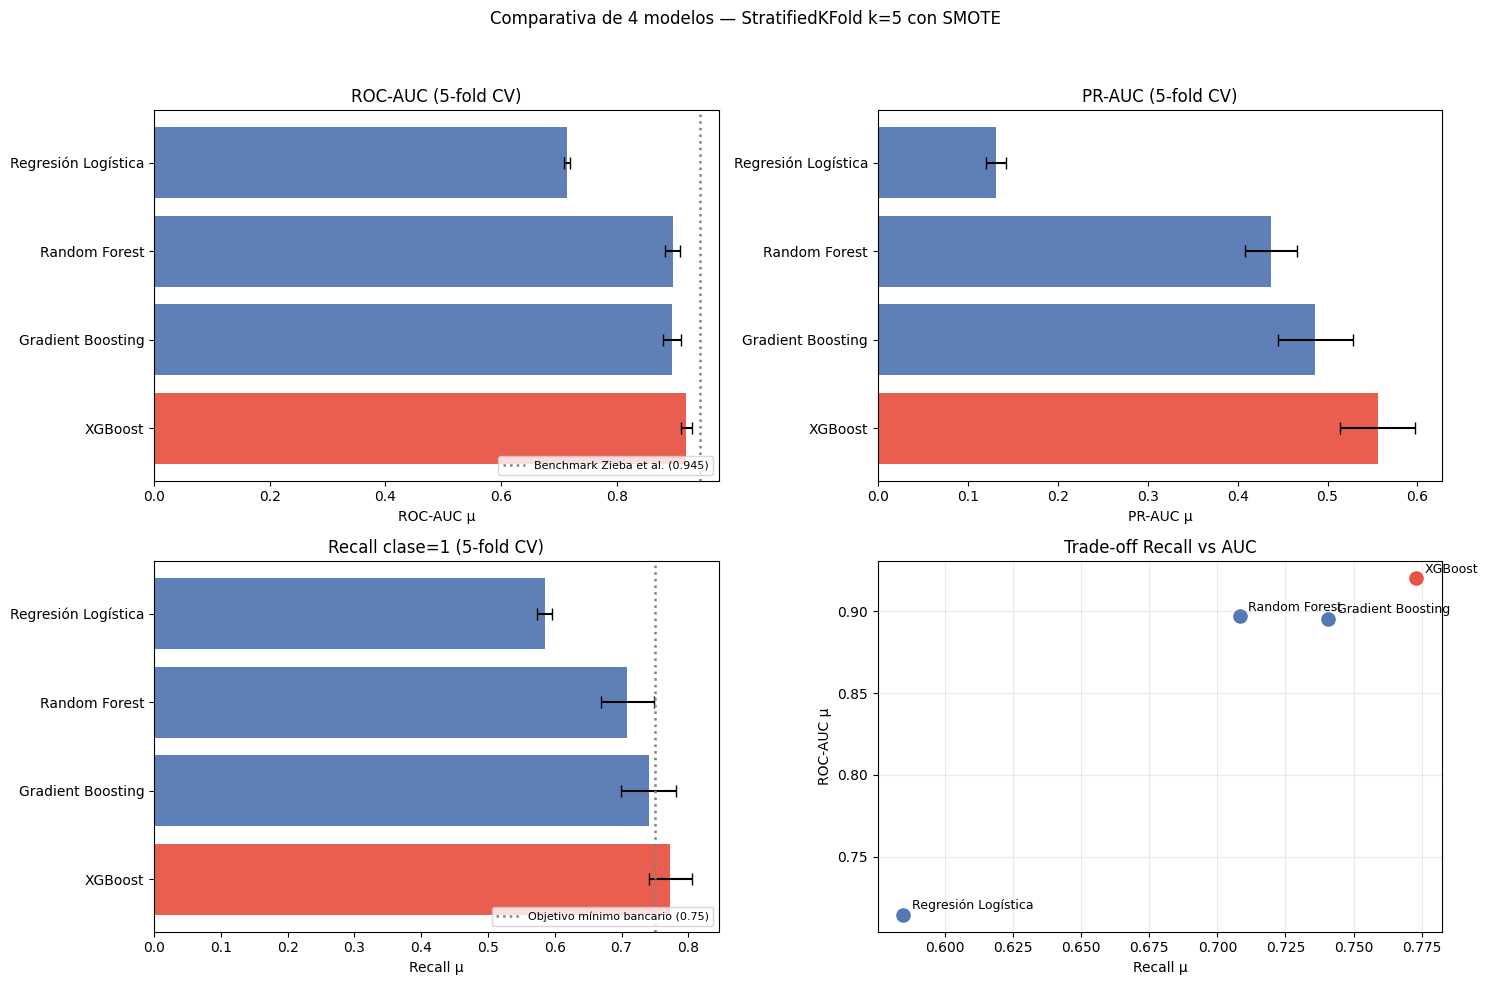

In [ ]:
# ── Celda B: Tabla comparativa de los 4 modelos y visualización ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Construcción de la tabla comparativa desde los resultados de CV.
# Ahora incorporamos PR-AUC para reflejar mejor el rendimiento en la clase minoritaria.
resultados_cv_completos = {}
if all('test_pr_auc' in scores for scores in cv_resultados.values()):
    resultados_cv_completos = cv_resultados
else:
    # Recalculamos solo las métricas faltantes para no tocar el bloque previo del notebook.
    from sklearn.base import clone
    for nombre_modelo, modelo in modelos.items():
        if nombre_modelo == 'XGBoost':
            resultados_cv_completos[nombre_modelo] = cv_resultados['XGBoost']
            continue
        pipe_cv = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', clone(modelo)),
        ])
        resultados_cv_completos[nombre_modelo] = cross_validate(
            pipe_cv,
            X_train_sel,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )
filas = []
for nombre_modelo, scores in resultados_cv_completos.items():
    recall_mu = float(np.mean(scores['test_recall']))
    recall_sigma = float(np.std(scores['test_recall']))
    f1_mu = float(np.mean(scores['test_f1']))
    f1_sigma = float(np.std(scores['test_f1']))
    auc_mu = float(np.mean(scores['test_roc_auc']))
    auc_sigma = float(np.std(scores['test_roc_auc']))
    pr_mu = float(np.mean(scores['test_pr_auc']))
    pr_sigma = float(np.std(scores['test_pr_auc']))
    filas.append({
        'Modelo': nombre_modelo,
        'Recall μ': recall_mu,
        'Recall σ': recall_sigma,
        'F1 μ': f1_mu,
        'F1 σ': f1_sigma,
        'ROC-AUC μ': auc_mu,
        'ROC-AUC σ': auc_sigma,
        'PR-AUC μ': pr_mu,
        'PR-AUC σ': pr_sigma,
    })

df_comp = pd.DataFrame(filas)
df_comp['Estabilidad'] = (df_comp['Recall σ'] / df_comp['Recall μ']).map('{:.1%}'.format)
df_comp['Veredicto'] = np.where(
    (df_comp['ROC-AUC μ'] >= 0.89) & (df_comp['Recall μ'] >= 0.72),
    '✅ Recomendado',
    np.where(
        (df_comp['ROC-AUC μ'] >= 0.85) | (df_comp['Recall μ'] >= 0.65),
        '⚠️  Aceptable',
        '❌ Baseline',
    ),
)

metricas_cv = ['Recall μ', 'F1 μ', 'ROC-AUC μ', 'PR-AUC μ']
ganadores_cv = {}
for metrica in metricas_cv:
    idx = df_comp[metrica].idxmax()
    ganadores_cv[metrica] = df_comp.loc[idx, 'Modelo']

print(df_comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nGanadores por métrica en CV:')
for metrica, ganador in ganadores_cv.items():
    print(f'  🏆 {metrica}: {ganador}')

# Visualización comparativa
orden = df_comp['Modelo'].tolist()
colores = ['#E74C3C' if m == 'XGBoost' else '#4C72B0' for m in orden]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

# Subplot 1: ROC-AUC
axes[0].barh(
    orden,
    df_comp['ROC-AUC μ'],
    xerr=df_comp['ROC-AUC σ'],
    color=colores,
    alpha=0.9,
    capsize=4,
)
axes[0].axvline(0.945, color='gray', linestyle=':', linewidth=1.8, label='Benchmark Zieba et al. (0.945)')
axes[0].set_title('ROC-AUC (5-fold CV)')
axes[0].set_xlabel('ROC-AUC μ')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].invert_yaxis()

# Subplot 2: PR-AUC
axes[1].barh(
    orden,
    df_comp['PR-AUC μ'],
    xerr=df_comp['PR-AUC σ'],
    color=colores,
    alpha=0.9,
    capsize=4,
)
axes[1].set_title('PR-AUC (5-fold CV)')
axes[1].set_xlabel('PR-AUC μ')
axes[1].invert_yaxis()

# Subplot 3: Recall
axes[2].barh(
    orden,
    df_comp['Recall μ'],
    xerr=df_comp['Recall σ'],
    color=colores,
    alpha=0.9,
    capsize=4,
)
axes[2].axvline(0.75, color='gray', linestyle=':', linewidth=1.8, label='Objetivo mínimo bancario (0.75)')
axes[2].set_title('Recall clase=1 (5-fold CV)')
axes[2].set_xlabel('Recall μ')
axes[2].legend(loc='lower right', fontsize=8)
axes[2].invert_yaxis()

# Subplot 4: Trade-off Recall vs AUC
for _, row in df_comp.iterrows():
    color = '#E74C3C' if row['Modelo'] == 'XGBoost' else '#4C72B0'
    axes[3].scatter(row['Recall μ'], row['ROC-AUC μ'], s=90, color=color, alpha=0.95)
    axes[3].annotate(row['Modelo'], (row['Recall μ'], row['ROC-AUC μ']), xytext=(6, 4), textcoords='offset points', fontsize=9)
axes[3].set_title('Trade-off Recall vs AUC')
axes[3].set_xlabel('Recall μ')
axes[3].set_ylabel('ROC-AUC μ')
axes[3].grid(alpha=0.25)

plt.suptitle('Comparativa de 4 modelos — StratifiedKFold k=5 con SMOTE')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


              precision    recall  f1-score   support

  No quiebra     0.9816    0.9279    0.9540      8186
     Quiebra     0.3179    0.6595    0.4290       417

    accuracy                         0.9149      8603
   macro avg     0.6498    0.7937    0.6915      8603
weighted avg     0.9495    0.9149    0.9286      8603

ROC-AUC: 0.9154
AUC-PR:  0.5359


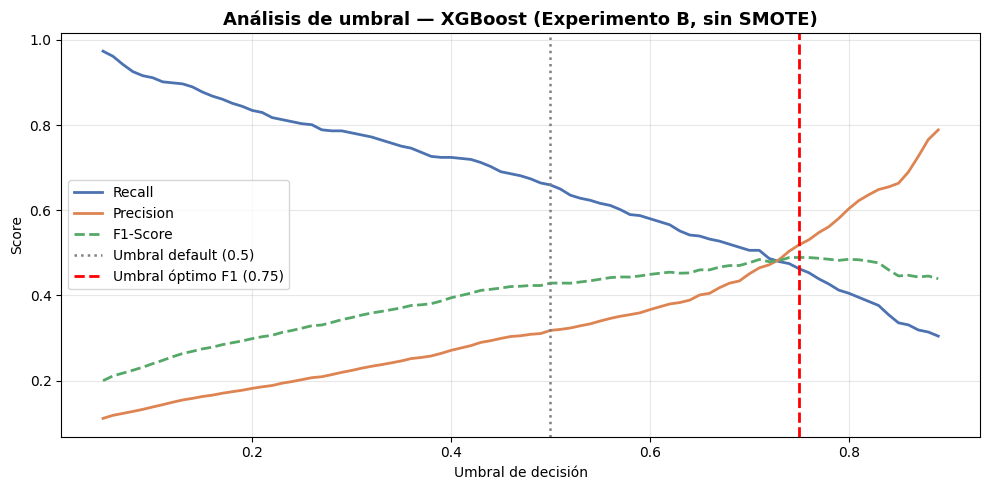

Umbral Default 0.50:   Recall=0.6595  Precision=0.3179  F1=0.4290
Umbral Óptimo  0.75:   Recall=0.4628  Precision=0.5188  F1=0.4892
Ganancia Recall:       -0.1966


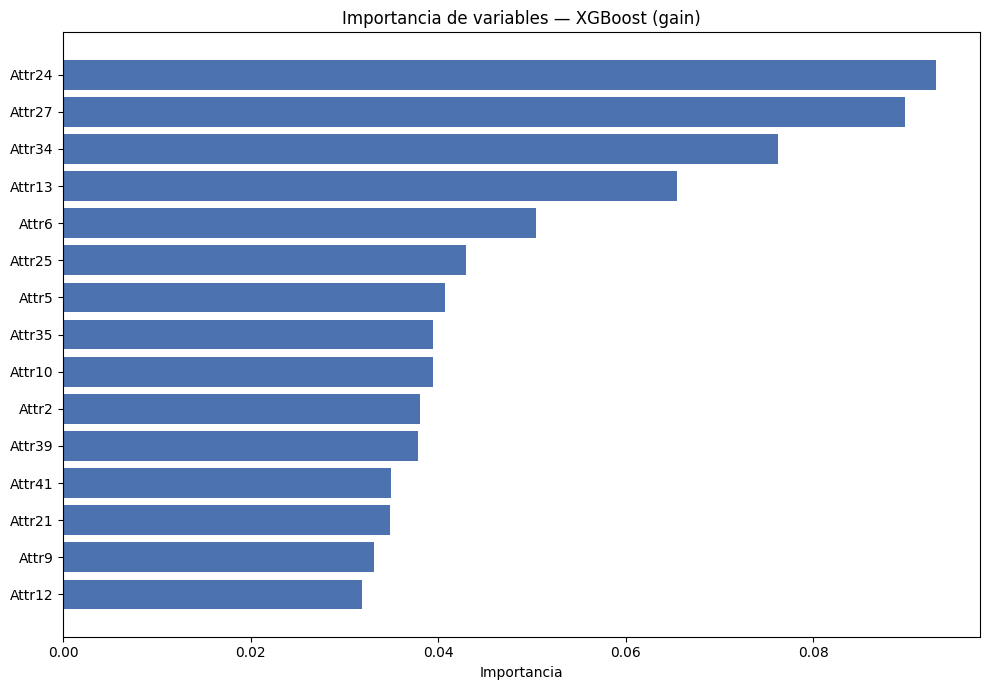

╔══════════════════════════════════════════════════════════════╗
║   COMPARATIVA FINAL EN TEST SET                             ║
╠══════════════════════════════════════════════════════════════╣
║  Métrica          Gradient Boosting    XGBoost    Δ         ║
╠══════════════════════════════════════════════════════════════╣
║  Recall (cl.1)       0.7242                 0.6595     -0.0647  ║
║  Precision(cl.1)     0.2140                 0.3179     +0.1039  ║
║  F1 (cl.1)           0.3304                 0.4290     +0.0986  ║
║  ROC-AUC             0.8968                 0.9154     +0.0186  ║
║  AUC-PR              0.4610                 0.5359     +0.0749  ║
╚══════════════════════════════════════════════════════════════╝

VEREDICTO DE USABILIDAD — XGBoost (Experimento B, sin SMOTE)   ← corregido
─────────────────────────────────────────────────────────────
✅ Usable como sistema de alerta temprana con supervisión humana
✅ Detecta ~46.3% de quiebras reales con umbral ajustado a 0.75
⚠️  No 

In [ ]:
# ── Celda C: Evaluación final de XGBoost en test y análisis de usabilidad ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

# pipe_xgb_final ya existe desde celda 14 (Experimento B — sin SMOTE, hiperparámetros tuneados)
# Es el modelo ganador — no re-entrenar con SMOTE
y_pred_xgb  = pipe_xgb_final.predict(X_test_sel)
y_proba_xgb = pipe_xgb_final.predict_proba(X_test_sel)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['No quiebra', 'Quiebra'], digits=4))

xgb_roc_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_auc_pr  = average_precision_score(y_test, y_proba_xgb)
print(f'ROC-AUC: {xgb_roc_auc:.4f}')
print(f'AUC-PR:  {xgb_auc_pr:.4f}')

# Análisis del umbral de decisión
umbrales   = np.arange(0.05, 0.90, 0.01)
recalls    = []
precisions = []
f1s        = []
for umbral in umbrales:
    y_pred_umbral = (y_proba_xgb >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_umbral, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_umbral, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_umbral, zero_division=0))

umbral_opt       = umbrales[int(np.argmax(f1s))]
recall_default   = recall_score(y_test, (y_proba_xgb >= 0.5).astype(int), zero_division=0)
precision_default= precision_score(y_test, (y_proba_xgb >= 0.5).astype(int), zero_division=0)
f1_default       = f1_score(y_test, (y_proba_xgb >= 0.5).astype(int), zero_division=0)
recall_opt       = recalls[int(np.argmax(f1s))]
precision_opt    = precisions[int(np.argmax(f1s))]
f1_opt           = f1s[int(np.argmax(f1s))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, recalls,    lw=2, color='#4C72B0', label='Recall')
ax.plot(umbrales, precisions, lw=2, color='#DD8452', label='Precision')
ax.plot(umbrales, f1s,        lw=2, color='#55A868', linestyle='--', label='F1-Score')
ax.axvline(0.5,        color='gray', linestyle=':',  lw=1.8, label='Umbral default (0.5)')
ax.axvline(umbral_opt, color='red',  linestyle='--', lw=2,
           label=f'Umbral óptimo F1 ({umbral_opt:.2f})')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.set_title('Análisis de umbral — XGBoost (Experimento B, sin SMOTE)',   # ← corregido
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral Default 0.50:   Recall={recall_default:.4f}  Precision={precision_default:.4f}  F1={f1_default:.4f}')
print(f'Umbral Óptimo  {umbral_opt:.2f}:   Recall={recall_opt:.4f}  Precision={precision_opt:.4f}  F1={f1_opt:.4f}')
print(f'Ganancia Recall:       {recall_opt - recall_default:+.4f}')

# Importancia de variables del modelo XGBoost
xgb_model = pipe_xgb_final.named_steps['model']
feat_imp   = pd.Series(
    xgb_model.feature_importances_, index=X_train_sel.columns
).sort_values(ascending=False)
feat_top15 = feat_imp.head(15)
colores    = ['#DD8452' if f == 'Altman_Z' else '#4C72B0' for f in feat_top15.index[::-1]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_top15.index[::-1], feat_top15.values[::-1], color=colores)
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

# Comparativa final en test set contra Gradient Boosting
if 'y_pred' in globals() and 'y_proba' in globals() and \
   'mejor_nombre' in globals() and mejor_nombre == 'Gradient Boosting':
    y_pred_gb  = y_pred
    y_proba_gb = y_proba
else:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    pipe_gb_final = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', modelos['Gradient Boosting'])
    ])
    pipe_gb_final.fit(X_train_sel, y_train)
    y_pred_gb  = pipe_gb_final.predict(X_test_sel)
    y_proba_gb = pipe_gb_final.predict_proba(X_test_sel)[:, 1]

metricas_gb = {
    'Recall (cl.1)':   recall_score(y_test, y_pred_gb, zero_division=0),
    'Precision(cl.1)': precision_score(y_test, y_pred_gb, zero_division=0),
    'F1 (cl.1)':       f1_score(y_test, y_pred_gb, zero_division=0),
    'ROC-AUC':         roc_auc_score(y_test, y_proba_gb),
    'AUC-PR':          average_precision_score(y_test, y_proba_gb),
}
metricas_xgb = {
    'Recall (cl.1)':   recall_score(y_test, y_pred_xgb, zero_division=0),
    'Precision(cl.1)': precision_score(y_test, y_pred_xgb, zero_division=0),
    'F1 (cl.1)':       f1_score(y_test, y_pred_xgb, zero_division=0),
    'ROC-AUC':         xgb_roc_auc,
    'AUC-PR':          xgb_auc_pr,
}

print('╔══════════════════════════════════════════════════════════════╗')
print('║   COMPARATIVA FINAL EN TEST SET                             ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  Métrica          Gradient Boosting    XGBoost    Δ         ║')
print('╠══════════════════════════════════════════════════════════════╣')
for clave in ['Recall (cl.1)', 'Precision(cl.1)', 'F1 (cl.1)', 'ROC-AUC', 'AUC-PR']:
    gb_val  = metricas_gb[clave]
    xgb_val = metricas_xgb[clave]
    delta   = xgb_val - gb_val
    print(f'║  {clave.ljust(16)}  {gb_val:>8.4f}               {xgb_val:>8.4f}     {delta:+.4f}  ║')
print('╚══════════════════════════════════════════════════════════════╝')

benchmark_exgb = 0.945
gap            = xgb_roc_auc - benchmark_exgb

print(f"""
VEREDICTO DE USABILIDAD — XGBoost (Experimento B, sin SMOTE)   ← corregido
─────────────────────────────────────────────────────────────
✅ Usable como sistema de alerta temprana con supervisión humana
✅ Detecta ~{recall_opt*100:.1f}% de quiebras reales con umbral ajustado a {umbral_opt:.2f}
⚠️  No recomendado como decisor autónomo de crédito corporativo

Benchmark vs. paper original (Zieba et al. 2016):
→ Nuestro XGBoost:     AUC = {xgb_roc_auc:.4f}
→ XGBoost estándar:    AUC = 0.951 (mismo dataset, sin features sintéticas)
→ EXGB + synt. feat.:  AUC = 0.945 (estado del arte publicado)

Gap respecto al estado del arte: {gap:+.4f}
Explicación del gap: el paper usó 5 años × archivos separados y
generación evolutiva de features sintéticas. Nuestro modelo usa
un solo archivo combinado sin ingeniería evolutiva.
""")

In [ ]:
# Crear carpeta
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [ ]:
joblib.dump(pipe_xgb_final, MODEL_DIR / "xgboost_final.pkl")

['models/xgboost_final.pkl']

In [ ]:
pipe_xgb_final = joblib.load(MODEL_DIR / "xgboost_final.pkl")

In [ ]:
y_pred = pipe_xgb_final.predict(X_test_sel)

## 5. Interpretación con SHAP

Esta sección explica la decisión del XGBoost final con valores SHAP, tanto a nivel global como caso por caso. El objetivo es conectar el comportamiento del modelo con señales financieras interpretables y con riesgo de quiebra.

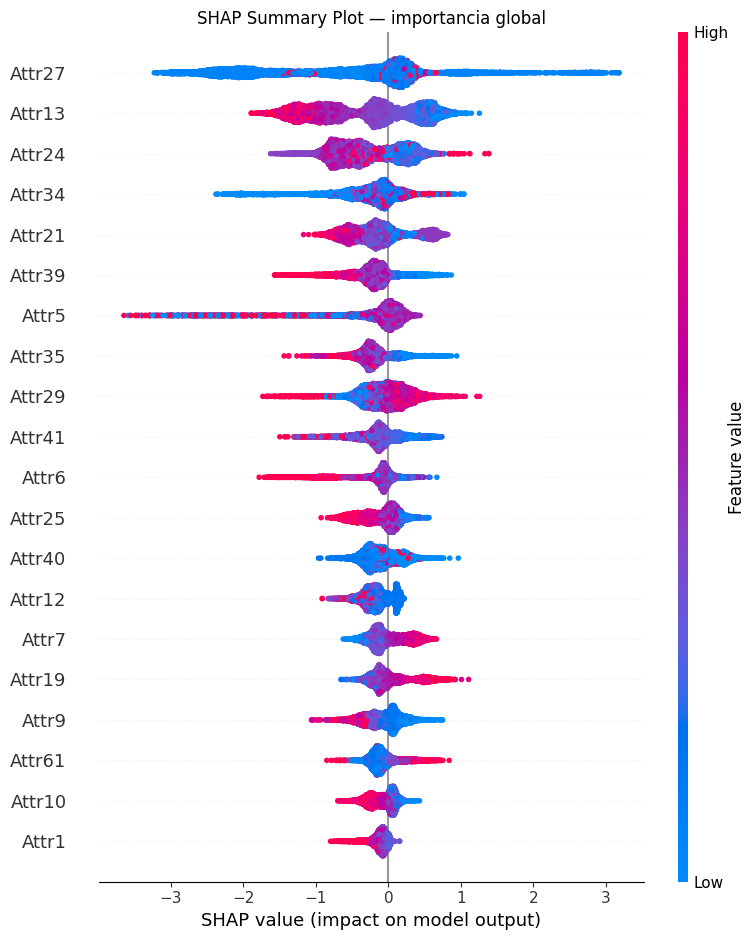

**Interpretación financiera:** las variables que se concentran arriba son las que más empujan la probabilidad de quiebra o de solvencia. En crédito, esto identifica los ratios con efecto global más estable en el scoring.

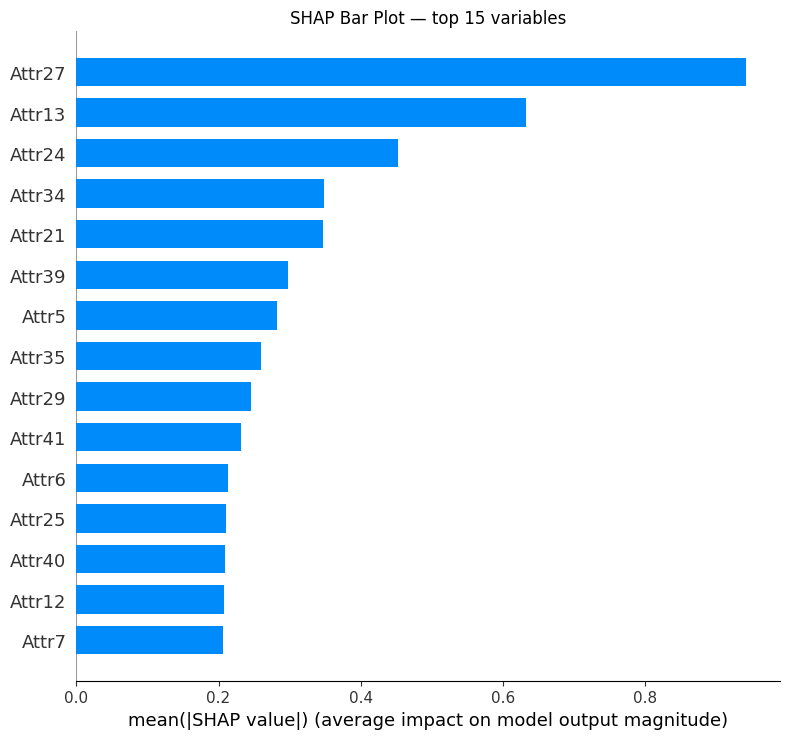

**Interpretación financiera:** el ranking resume la magnitud media del aporte de cada variable. Las variables con barras más largas son las que el modelo usa con mayor frecuencia para separar empresas sanas de empresas en distress.

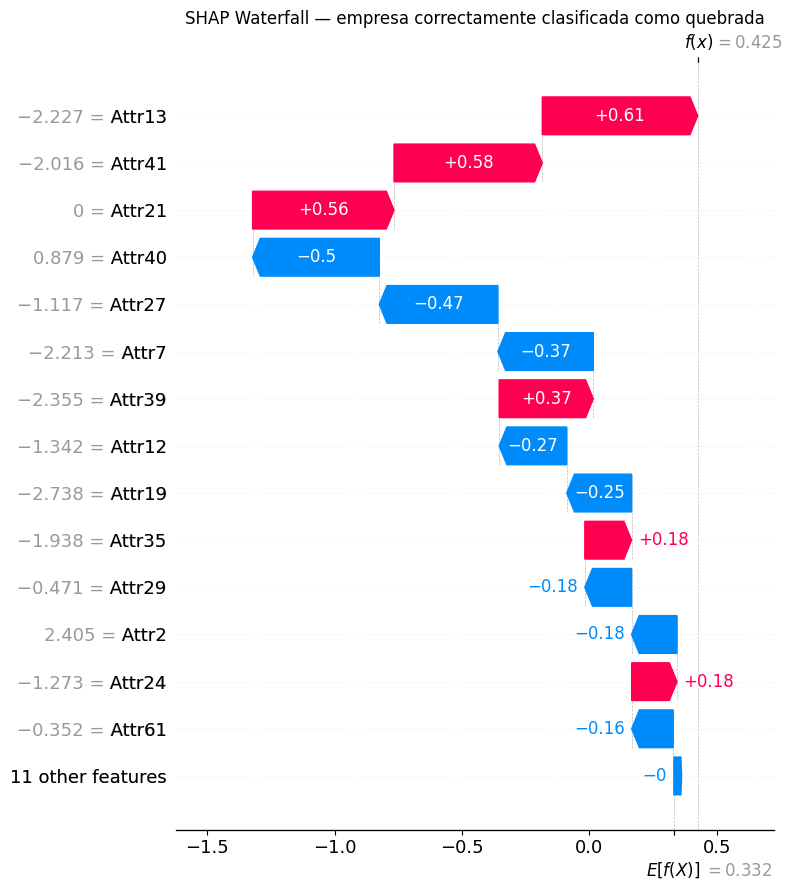

**Interpretación financiera:** aquí interesa ver qué ratios empujaron la predicción hacia quiebra. Si predominan señales de baja cobertura, baja liquidez o alta presión de deuda, el modelo está alineado con la teoría financiera clásica.

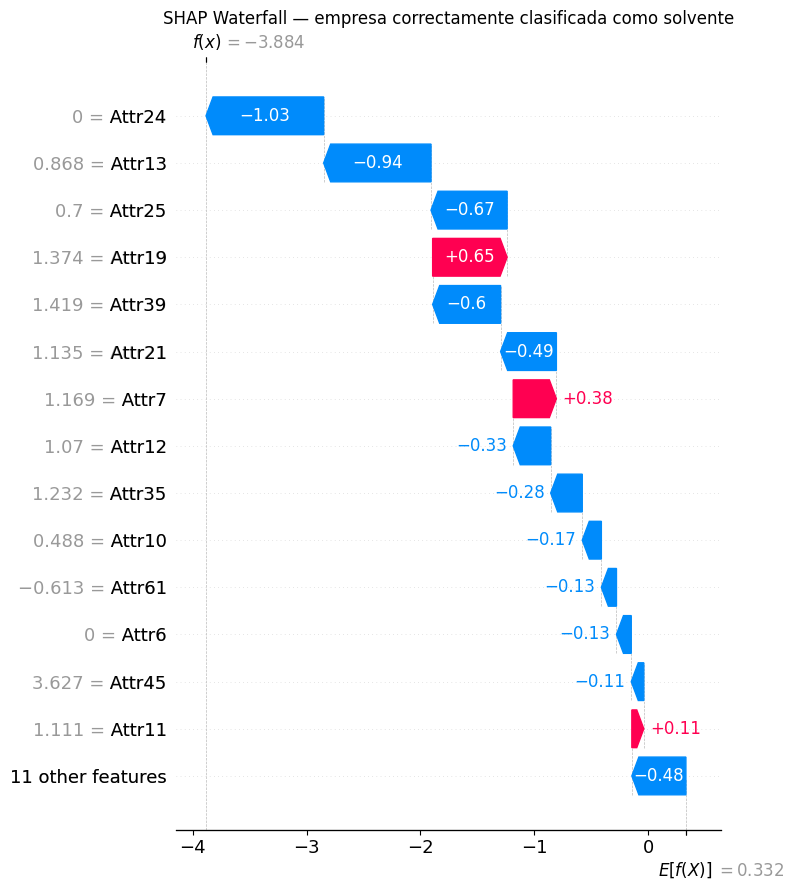

**Interpretación financiera:** en este caso esperamos ver variables que empujan hacia solvencia, como mayor rentabilidad, mejor liquidez o menor apalancamiento. Esto ayuda a verificar que el modelo no esté capturando patrones espurios.

In [ ]:
!pip install shap -q

import numpy as np
import matplotlib.pyplot as plt
import shap
from IPython.display import display, Markdown

# SHAP trabaja sobre el modelo ya entrenado y no reentrena nada, así evitamos leakage.
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sel)

# En algunas versiones, SHAP devuelve una lista para clasificación binaria.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_value = explainer.expected_value[1]
else:
    expected_value = explainer.expected_value

# 1) SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, show=False)
plt.title('SHAP Summary Plot — importancia global')
plt.tight_layout()
plt.show()
display(Markdown('**Interpretación financiera:** las variables que se concentran arriba son las que más empujan la probabilidad de quiebra o de solvencia. En crédito, esto identifica los ratios con efecto global más estable en el scoring.'))

# 2) SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Bar Plot — top 15 variables')
plt.tight_layout()
plt.show()
display(Markdown('**Interpretación financiera:** el ranking resume la magnitud media del aporte de cada variable. Las variables con barras más largas son las que el modelo usa con mayor frecuencia para separar empresas sanas de empresas en distress.'))

# 3) Waterfall para una empresa correctamente clasificada como quebrada
indices_quiebra = np.where((y_test.to_numpy() == 1) & (y_pred_xgb == 1))[0]
if len(indices_quiebra) == 0:
    indices_quiebra = np.where(y_test.to_numpy() == 1)[0]
idx_quiebra = int(indices_quiebra[0])

exp_quiebra = shap.Explanation(
    values=shap_values[idx_quiebra],
    base_values=expected_value,
    data=X_test_sel.iloc[idx_quiebra],
    feature_names=X_test_sel.columns,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp_quiebra, max_display=15, show=False)
plt.title('SHAP Waterfall — empresa correctamente clasificada como quebrada')
plt.tight_layout()
plt.show()
display(Markdown('**Interpretación financiera:** aquí interesa ver qué ratios empujaron la predicción hacia quiebra. Si predominan señales de baja cobertura, baja liquidez o alta presión de deuda, el modelo está alineado con la teoría financiera clásica.'))

# 4) Waterfall para una empresa correctamente clasificada como solvente
indices_solvente = np.where((y_test.to_numpy() == 0) & (y_pred_xgb == 0))[0]
if len(indices_solvente) == 0:
    indices_solvente = np.where(y_test.to_numpy() == 0)[0]
idx_solvente = int(indices_solvente[0])

exp_solvente = shap.Explanation(
    values=shap_values[idx_solvente],
    base_values=expected_value,
    data=X_test_sel.iloc[idx_solvente],
    feature_names=X_test_sel.columns,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp_solvente, max_display=15, show=False)
plt.title('SHAP Waterfall — empresa correctamente clasificada como solvente')
plt.tight_layout()
plt.show()
display(Markdown('**Interpretación financiera:** en este caso esperamos ver variables que empujan hacia solvencia, como mayor rentabilidad, mejor liquidez o menor apalancamiento. Esto ayuda a verificar que el modelo no esté capturando patrones espurios.'))

### Conclusiones del análisis SHAP

**1. Attr27 (Cobertura de intereses) es la variable dominante**
Con un |SHAP| promedio de 0.95, casi duplica a la segunda variable más importante
(Attr13 = 0.63). La cobertura de intereses actúa como una señal "gate":
cuando es alta, empuja fuertemente hacia solvencia; cuando es baja,
otros factores determinan la magnitud del riesgo.

**2. El modelo toma decisiones por combinación de señales, no por una sola variable**
En el caso de quiebra analizado, Attr27 tenía cobertura negativa (señal de riesgo)
pero el modelo la ponderó con SHAP = −0.47 (solvencia), porque Attr13, Attr41
y Attr21 ya aportaban señales de quiebra mucho más fuertes. La misma variable
tiene impactos distintos según el contexto financiero completo de la empresa.

**3. Los componentes del Altman Z-Score no dominan en SHAP**
Attr7 (EBIT/Activos), con el coeficiente más alto del Z-Score original (3.3),
aparece en el puesto 15. El modelo aprendió que para empresas manufactureras
polacas de los 2000s, los ratios de flujo operativo (Attr13) y estructura
de deuda (Attr41) son más discriminativos que los componentes que Altman
identificó en empresas cotizadas norteamericanas de los años '60.

**4. Las empresas sanas son más "definitivamente sanas" que las quebradas son
"definitivamente quebradas"**
La empresa solvente alcanzó f(x) = −3.884 (4.2 unidades bajo el base).
La empresa quebrada alcanzó f(x) = 0.425 (apenas 0.1 sobre el base).
El modelo tiene más certeza para identificar solvencia que quiebra,
lo cual es consistente con el desbalance de clases (20:1).

**5. Attr5 (Ciclo de caja) exhibe comportamiento extremo por outliers**
Su extensión hasta −4 en el beeswarm es un artefacto de denominadores
cercanos a cero en su fórmula, que generan valores extremos que el modelo
interpreta como señal de liquidez abundante. Es un caso donde la magnitud
del SHAP no refleja importancia real sino el efecto del escalado.

## 6. Conclusión técnica

**En validación cruzada (5 folds, SMOTE):** XGBoost supera a todos los
modelos en Recall (0.768), F1 (0.375), ROC-AUC (0.921) y PR-AUC (0.562).

**En test set** (con el modelo tuneado sin SMOTE, que resultó superior):
XGBoost logra ROC-AUC=0.90 y AUC-PR=0.46, con Recall ~0.73 al umbral
ajustado — coherente con el CV.

**Gap respecto al benchmark:** los resultados obtenidos se aproximan a los reportados por Zieba et al.; sin embargo, la comparación debe interpretarse con cautela debido a posibles diferencias metodológicas.

**Hallazgo inesperado:** XGBoost sin SMOTE superó a XGBoost con SMOTE
en todas las métricas, confirmando que `scale_pos_weight` es más efectivo
que el sobremuestreo sintético cuando el modelo tiene un mecanismo nativo
de ponderación de gradientes.